In [1]:
import pandas as pd

In [17]:
house_prices = pd.read_csv(
    "house_price_index_europe.csv",
    encoding="cp1252"
)

In [ ]:
print(house_prices.head())


                                        Year   2015 Unnamed: 2    2016  \
0                                  Countries    NaN        NaN     NaN   
1  European Union - 27 countries (from 2020)  100.0        NaN  104.31   
2       Euro area ? 21 countries (from 2026)  100.0        NaN  104.04   
3       Euro area ? 20 countries (2023-2025)  100.0        NaN  104.01   
4                                    Belgium  100.0        NaN  102.33   

  Unnamed: 4    2017 Unnamed: 6    2018 Unnamed: 8    2019  ...    2020  \
0        NaN     NaN        NaN     NaN        NaN     NaN  ...     NaN   
1        NaN  109.31        NaN  114.81        NaN  120.40  ...  127.14   
2        NaN  108.66        NaN  113.92        NaN  118.96  ...  125.23   
3        NaN  108.59        NaN  113.83        NaN  118.84  ...  125.11   
4        NaN  105.95        NaN  109.15        NaN  113.23  ...  118.09   

   Unnamed: 12    2021  Unnamed: 14    2022  Unnamed: 16    2023  Unnamed: 18  \
0          NaN     NaN 

In [20]:
house_prices = house_prices.loc[:, ~house_prices.columns.str.contains('Unnamed')]

In [21]:
print(house_prices.columns)

Index(['Year', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024'],
      dtype='str')


In [22]:
house_prices.rename(columns={'Year': 'country'}, inplace=True)

In [23]:
house_prices = house_prices[
    ~house_prices['country'].str.contains('European|Euro', na=False)
]

In [24]:
house_prices_long = house_prices.melt(
    id_vars='country',
    var_name='year',
    value_name='house_price_index'
)

In [25]:
house_prices_long['house_price_index'] = (
    house_prices_long['house_price_index']
    .astype(str)
    .str.extract(r'([\d\.]+)')
)

In [26]:
house_prices_long['year'] = pd.to_numeric(
    house_prices_long['year'], errors='coerce'
)

house_prices_long['house_price_index'] = pd.to_numeric(
    house_prices_long['house_price_index'], errors='coerce'
)

In [27]:
house_prices_long = house_prices_long.dropna()

In [28]:
house_prices_long.to_csv(
    "house_prices_clean.csv",
    index=False
)

In [64]:
import os
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

# Read credentials from environment variables
user = os.environ.get("MYSQL_USER")
password = os.environ.get("MYSQL_PASSWORD")

In [65]:
import os

print("MYSQL_USER:", os.environ.get("MYSQL_USER"))
print("MYSQL_PASSWORD:", os.environ.get("MYSQL_PASSWORD"))

MYSQL_USER: None
MYSQL_PASSWORD: None


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import numpy as np
sns.set(style="whitegrid")
import mysql.connector

In [35]:
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Voltaregion$$1",
    database="housing_project"
)

In [36]:
cursor = connection.cursor()
cursor.execute("SHOW TABLES")

for table in cursor:
    print(table)

('countries',)
('house_prices',)
('years',)


QUERRY 1- Which European countries experienced the fastest housing price growth between 2015 and 2024?

In [37]:
query1 = """
SELECT 
    country,
    MIN(house_price_index) AS starting_price,
    MAX(house_price_index) AS latest_price
FROM house_prices
GROUP BY country
ORDER BY latest_price DESC
"""

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19592\45371910.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql_query(query1, connection)


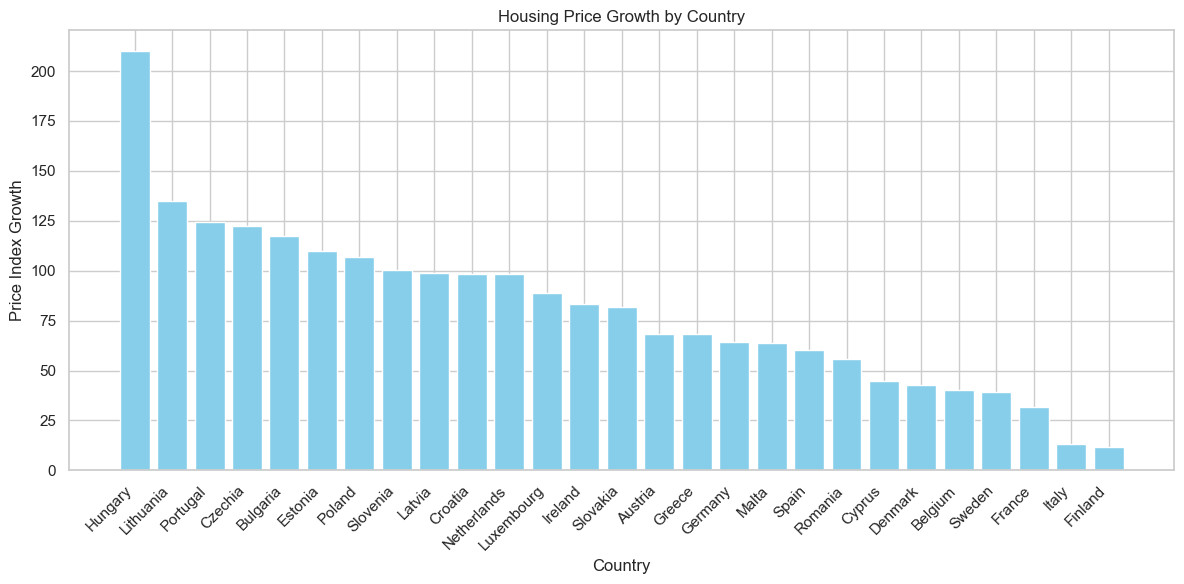

In [38]:
df1 = pd.read_sql_query(query1, connection)
df1["growth"] = df1["latest_price"] - df1["starting_price"]

# Plot with better handling of many countries
plt.figure(figsize=(12,6))
plt.bar(df1["country"], df1["growth"], color='skyblue')
plt.title("Housing Price Growth by Country")
plt.xlabel("Country")
plt.ylabel("Price Index Growth")
plt.xticks(rotation=45, ha="right")  # Tilt x labels and align
plt.tight_layout()  # Avoid cutting labels
plt.show()

QUERRY 2- What is the average price index of housing each year from 2015 to 2024?

In [39]:
query2 = """
SELECT 
    year,
    AVG(house_price_index) AS average_price
FROM house_prices
GROUP BY year
ORDER BY year
"""

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19592\1159076101.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(query2, connection)


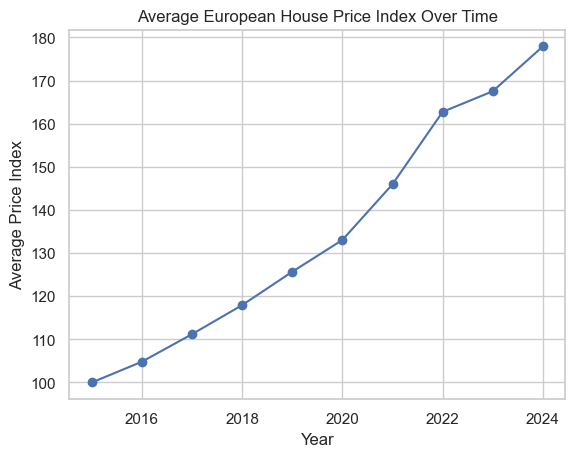

In [40]:
df2 = pd.read_sql(query2, connection)

plt.figure()

plt.plot(df2["year"], df2["average_price"], marker='o')

plt.title("Average European House Price Index Over Time")
plt.xlabel("Year")
plt.ylabel("Average Price Index")

plt.show()

QUERRY 3 - Which European countries currently have the highest housing price index?- Top 5 and Bottom 5 ranking?

In [41]:
query3 = """
SELECT 
    country,
    house_price_index
FROM house_prices
WHERE year = 2024
ORDER BY house_price_index DESC
"""

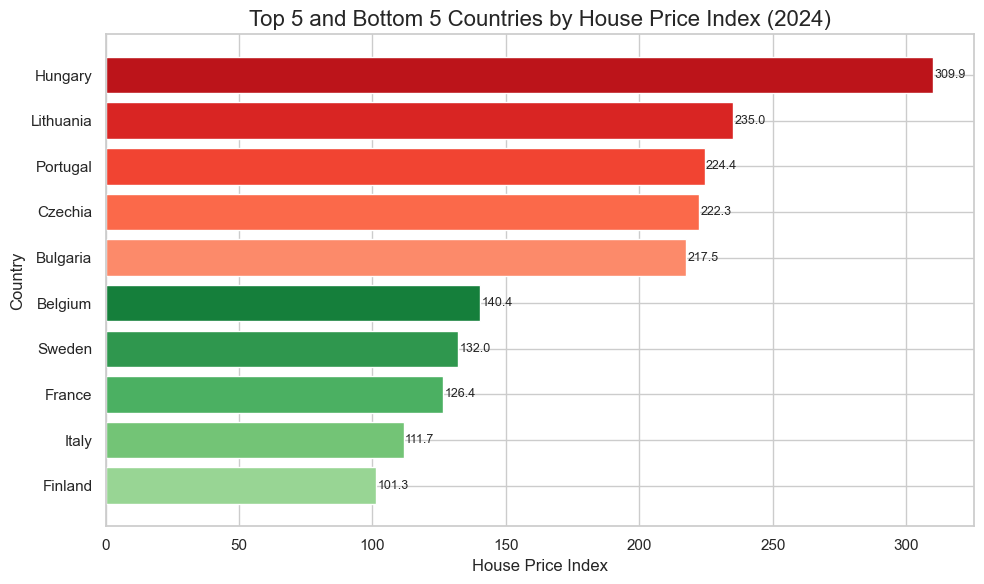

In [49]:

df_sorted = df3.sort_values("house_price_index", ascending=False)

# Select top 5 and bottom 5
df_top5 = df_sorted.head(5)
df_bottom5 = df_sorted.tail(5)
df_plot = pd.concat([df_top5, df_bottom5])

top_colors = [cm.Greens(x) for x in np.linspace(0.4, 0.8, 5)]

bottom_colors = [cm.Reds(x) for x in np.linspace(0.4, 0.8, 5)]

colors = top_colors + bottom_colors

# Plot horizontal bar chart
plt.figure(figsize=(10,6))
plt.barh(df_plot["country"][::-1], df_plot["house_price_index"][::-1], color=colors)
plt.title("Top 5 and Bottom 5 Countries by House Price Index (2024)", fontsize=16)
plt.xlabel("House Price Index", fontsize=12)
plt.ylabel("Country", fontsize=12)

for i, value in enumerate(df_plot["house_price_index"][::-1]):
    plt.text(value + 0.5, i, f"{value:.1f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()